## Problem Statement

- This project This investigates how demographic and socio-economic factors — **gender, race/ethnicity,
parental level of education, lunch type (a proxy for socio-economic status), and completion of a
test preparation course** — relate to student performance in **Math, Reading, and Writing**.

### 1. Import Libraries

In [146]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import ttest_ind

import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
ALPHA = 0.05  # significance level used throughout

### 2. Load Data

In [147]:
df = pd.read_csv('data/stud.csv')

### 3. Dataset Overview

In [148]:
df.shape

(1000, 8)

In [149]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [150]:
df.sample(5, random_state=RANDOM_STATE)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
521,female,group C,associate's degree,standard,none,91,86,84
737,female,group B,some college,free/reduced,completed,53,66,73
740,male,group D,bachelor's degree,standard,none,80,73,72
660,male,group C,some college,free/reduced,none,74,77,73
411,male,group E,some college,standard,completed,84,83,78


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [152]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,female,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race_ethnicity,1000,5,group C,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental_level_of_education,1000,6,some college,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test_preparation_course,1000,2,none,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math_score,1000.000,NaN,NaN,NaN,66.089,15.163,0.000,57.000,66.000,77.000,100.000
reading_score,1000.000,NaN,NaN,NaN,69.169,14.600,17.000,59.000,70.000,79.000,100.000
writing_score,1000.000,NaN,NaN,NaN,68.054,15.196,10.000,57.750,69.000,79.000,100.000


### 4. Data Quality

In [153]:
pd.DataFrame({
    'dtype': df.dtypes,
    'missing_values': df.isnull().sum(),
    'missing_%' : (df.isnull().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique()
})

,dtype,missing_values,missing_%,unique_values
gender,object,0,0.000,2
race_ethnicity,object,0,0.000,5
parental_level_of_education,object,0,0.000,6
lunch,object,0,0.000,2
test_preparation_course,object,0,0.000,2
math_score,int64,0,0.000,81
reading_score,int64,0,0.000,72
writing_score,int64,0,0.000,77


In [154]:
print("Duplicate Rows: ", df.duplicated().sum()) 

Duplicate Rows:  0


In [155]:
score_cols = ['math_score', 'reading_score', 'writing_score']
range_check = pd.DataFrame({
    'min': df[score_cols].min(),
    'max': df[score_cols].max(),
    'out_of_range_count': [((df[c] < 0) | (df[c] > 100)).sum() for c in score_cols]
})
range_check

,min,max,out_of_range_count
math_score,0,100,0
reading_score,17,100,0
writing_score,10,100,0


In [156]:
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print(f"We have {len(categorical_features)} categoriacal features: {categorical_features}")

We have 5 categoriacal features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [157]:
for column in categorical_features:
    print(f"{column} ({df[column].nunique()} categories):")
    print(sorted(df[column].unique()))
    print()

gender (2 categories):
['female', 'male']

race_ethnicity (5 categories):
['group A', 'group B', 'group C', 'group D', 'group E']

parental_level_of_education (6 categories):
["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']

lunch (2 categories):
['free/reduced', 'standard']

test_preparation_course (2 categories):
['completed', 'none']



**Data quality verdict:** No missing values, no duplicate rows, all scores fall within the
valid 0–100 range, and all categorical labels are clean (no typos, casing issues, or unexpected
categories). The dataset is analysis-ready with no imputation or cleaning required.

### 5. Feature Engineering

We derive a small set of features that will be used throughout the rest of the analysis:

- `total_score`, `average_score` — overall academic performance
- `pass_math` / `pass_reading` / `pass_writing` / `pass_overall` — pass flags using a 33-mark threshold, a common academic benchmark
- `performance_band` — a Grade A–F band derived from `average_score`, useful for stakeholder-facing reporting


In [158]:
df['total_score'] = df[score_cols].sum(axis=1)
df['average_score'] = (df['total_score'] / 3).round(2)

PASS_MARK = 33
df['pass_math'] = (df['math_score'] >= PASS_MARK).astype(int)
df['pass_reading'] = (df['reading_score'] >= PASS_MARK).astype(int)
df['pass_writing'] = (df['writing_score'] >= PASS_MARK).astype(int)
df['pass_overall'] = ((df['pass_math'] == 1) & (df['pass_reading'] == 1) & (df['pass_writing'] == 1)).astype(int)

def grade_band(score):
    if score >= 90: return 'A (90-100)'
    elif score >= 80: return 'B (80-89)'
    elif score >= 70: return 'C (70-79)'
    elif score >= 60: return 'D (60-69)'
    elif score >= 33: return 'E (33-59)'
    else: return 'F (<33)'

df['performance_band'] = df['average_score'].apply(grade_band)

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,pass_math,pass_reading,pass_writing,pass_overall,performance_band
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.670,1,1,1,1,C (70-79)
1,female,group C,some college,standard,completed,69,90,88,247,82.330,1,1,1,1,B (80-89)
2,female,group B,master's degree,standard,none,90,95,93,278,92.670,1,1,1,1,A (90-100)
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.330,1,1,1,1,E (33-59)
4,male,group C,some college,standard,none,76,78,75,229,76.330,1,1,1,1,C (70-79)


In [159]:
print(f"Overall pass rate: {df['pass_overall'].mean()*100:.2f}%")
df['performance_band'].value_counts().sort_index()

Overall pass rate: 97.80%


performance_band
A (90-100)     52
B (80-89)     146
C (70-79)     261
D (60-69)     256
E (33-59)     270
F (<33)        15
Name: count, dtype: int64

### 6. Univariate Analysis

#### 6.1 Numeric Features — Distribution, Shape & Outliers

For each score column we examine the histogram + KDE, boxplot, and quantify **skewness** and
**kurtosis** to describe distribution shape numerically rather than relying on visuals alone.

In [162]:
numeric_features = ['math_score', 'reading_score', 'writing_score', 'total_score', 'average_score']

In [163]:
shape_stats = pd.DataFrame({
    'mean': df[numeric_features].mean(),
    'median': df[numeric_features].median(),
    'std': df[numeric_features].std(),
    'skewness': df[numeric_features].skew(),
    'kurtosis': df[numeric_features].kurt()
}).round(3)
shape_stats

,mean,median,std,skewness,kurtosis
math_score,66.089,66.000,15.163,-0.279,0.275
reading_score,69.169,70.000,14.600,-0.259,-0.068
writing_score,68.054,69.000,15.196,-0.289,-0.033
total_score,203.312,205.000,42.772,-0.299,0.126
average_score,67.771,68.330,14.257,-0.299,0.126


**Reading skewness/kurtosis:** Skewness near 0 indicates a roughly symmetric distribution;
negative skew means a longer left tail (a cluster of low-scoring students dragging the mean down).
Kurtosis near 0 indicates tail-thickness similar to a normal distribution.

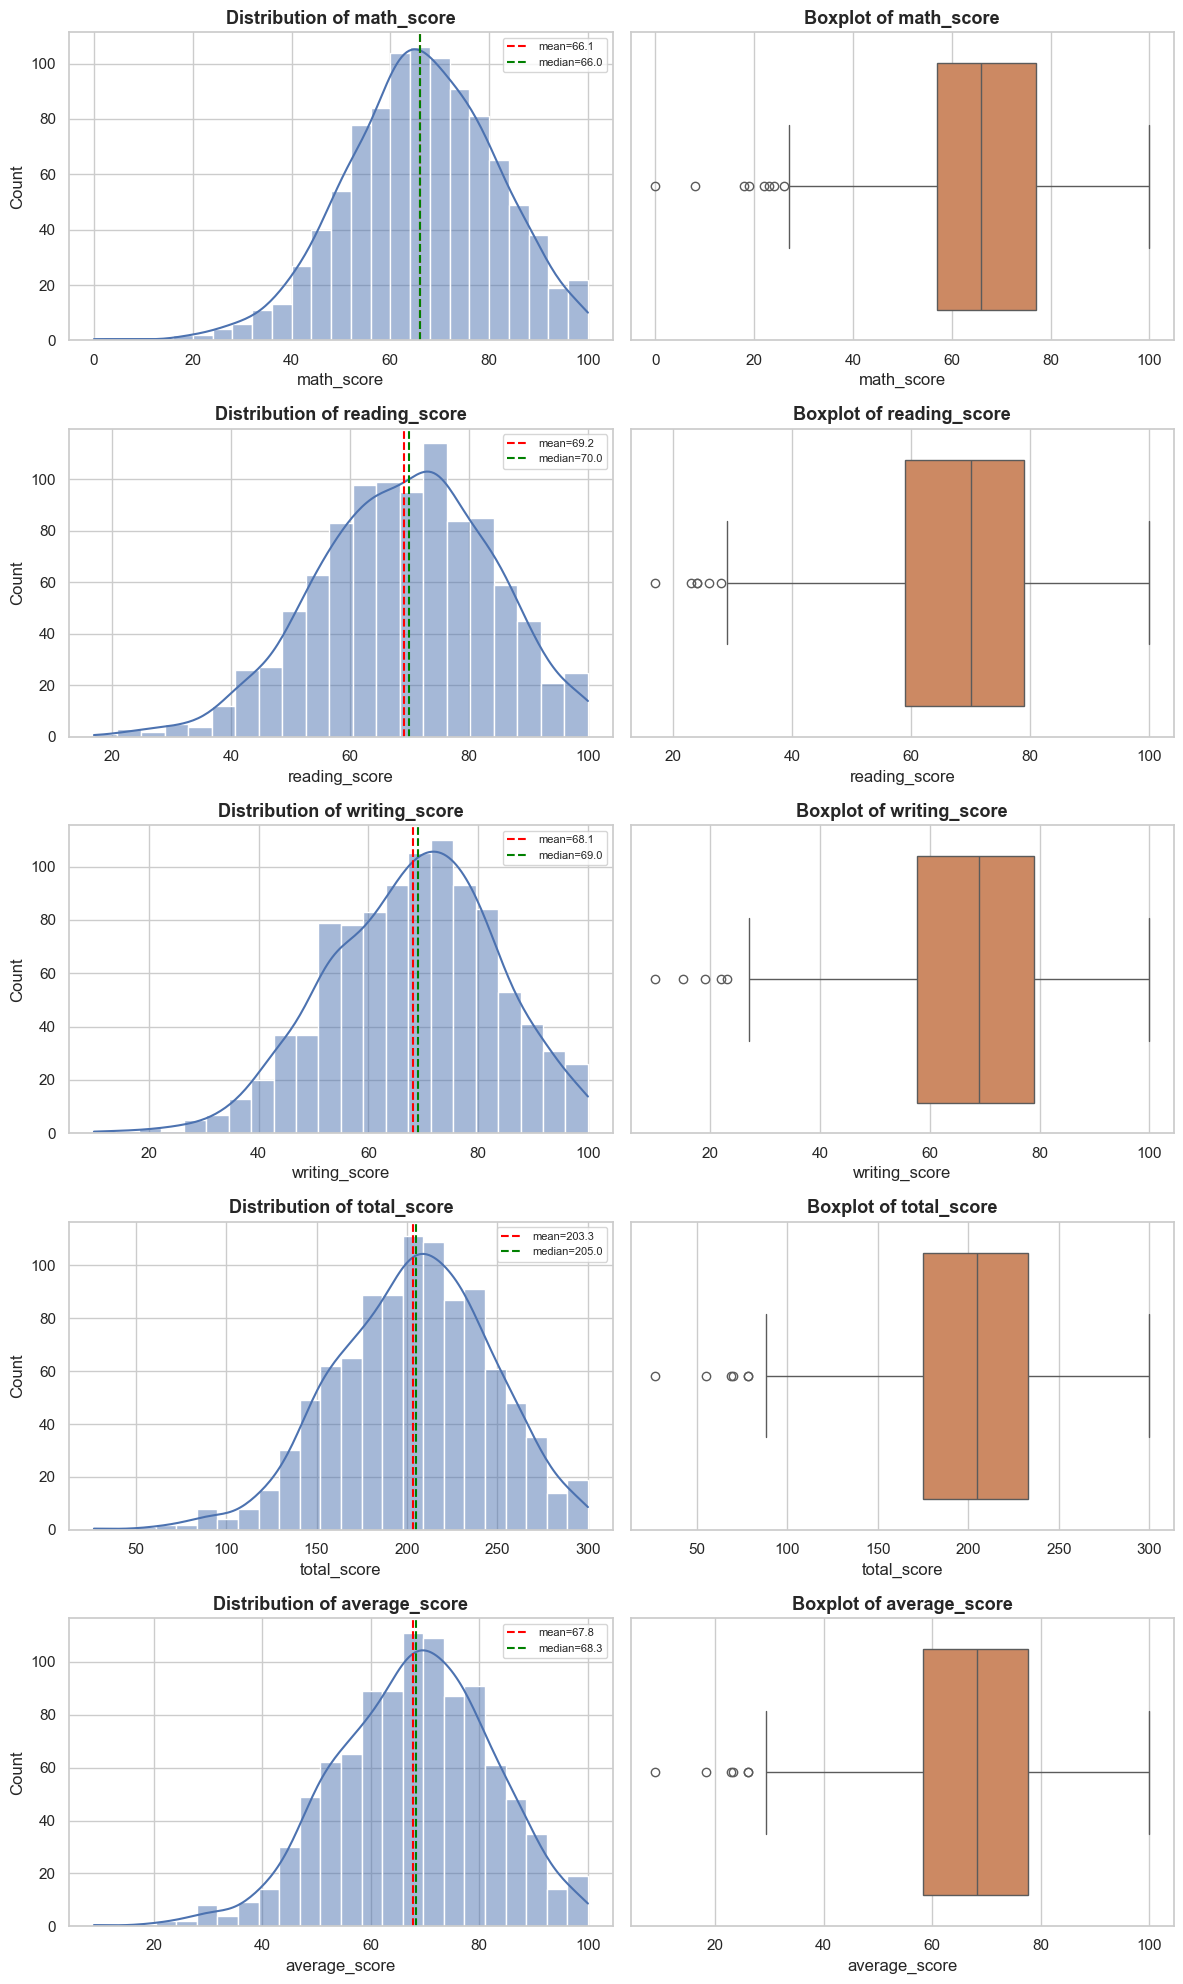

In [164]:
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(12, 4*len(numeric_features)))
for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='#4C72B0')
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', label=f'mean={df[col].mean():.1f}')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='--', label=f'median={df[col].median():.1f}')
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].legend(fontsize=8)

    sns.boxplot(x=df[col], ax=axes[i, 1], color='#DD8452')
    axes[i, 1].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

#### 6.2 Outlier Detection (IQR Method)

In [165]:
def iqr_outlier_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    return pd.Series({'Q1': q1, 'Q3': q3, 'IQR': iqr, 'lower_bound': lower,
                       'upper_bound': upper, 'n_outliers': n_outliers,
                       'outlier_%': round(n_outliers/len(series)*100, 2)})

outlier_summary = pd.DataFrame({col: iqr_outlier_summary(df[col]) for col in numeric_features}).T
outlier_summary

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_%
math_score,57.000,77.000,20.000,27.000,107.000,8.000,0.800
reading_score,59.000,79.000,20.000,29.000,109.000,6.000,0.600
writing_score,57.750,79.000,21.250,25.875,110.875,5.000,0.500
total_score,175.000,233.000,58.000,88.000,320.000,6.000,0.600
average_score,58.330,77.670,19.340,29.320,106.680,6.000,0.600


**Outlier verdict:** Outlier counts are low (typically low-scoring students on the tail) and
are genuine, plausible exam scores — not data-entry errors — so they are retained rather than removed.
Removing legitimate low performers would bias the analysis toward optimistic conclusions.

#### 6.3 Categorical Features — Frequency Distribution

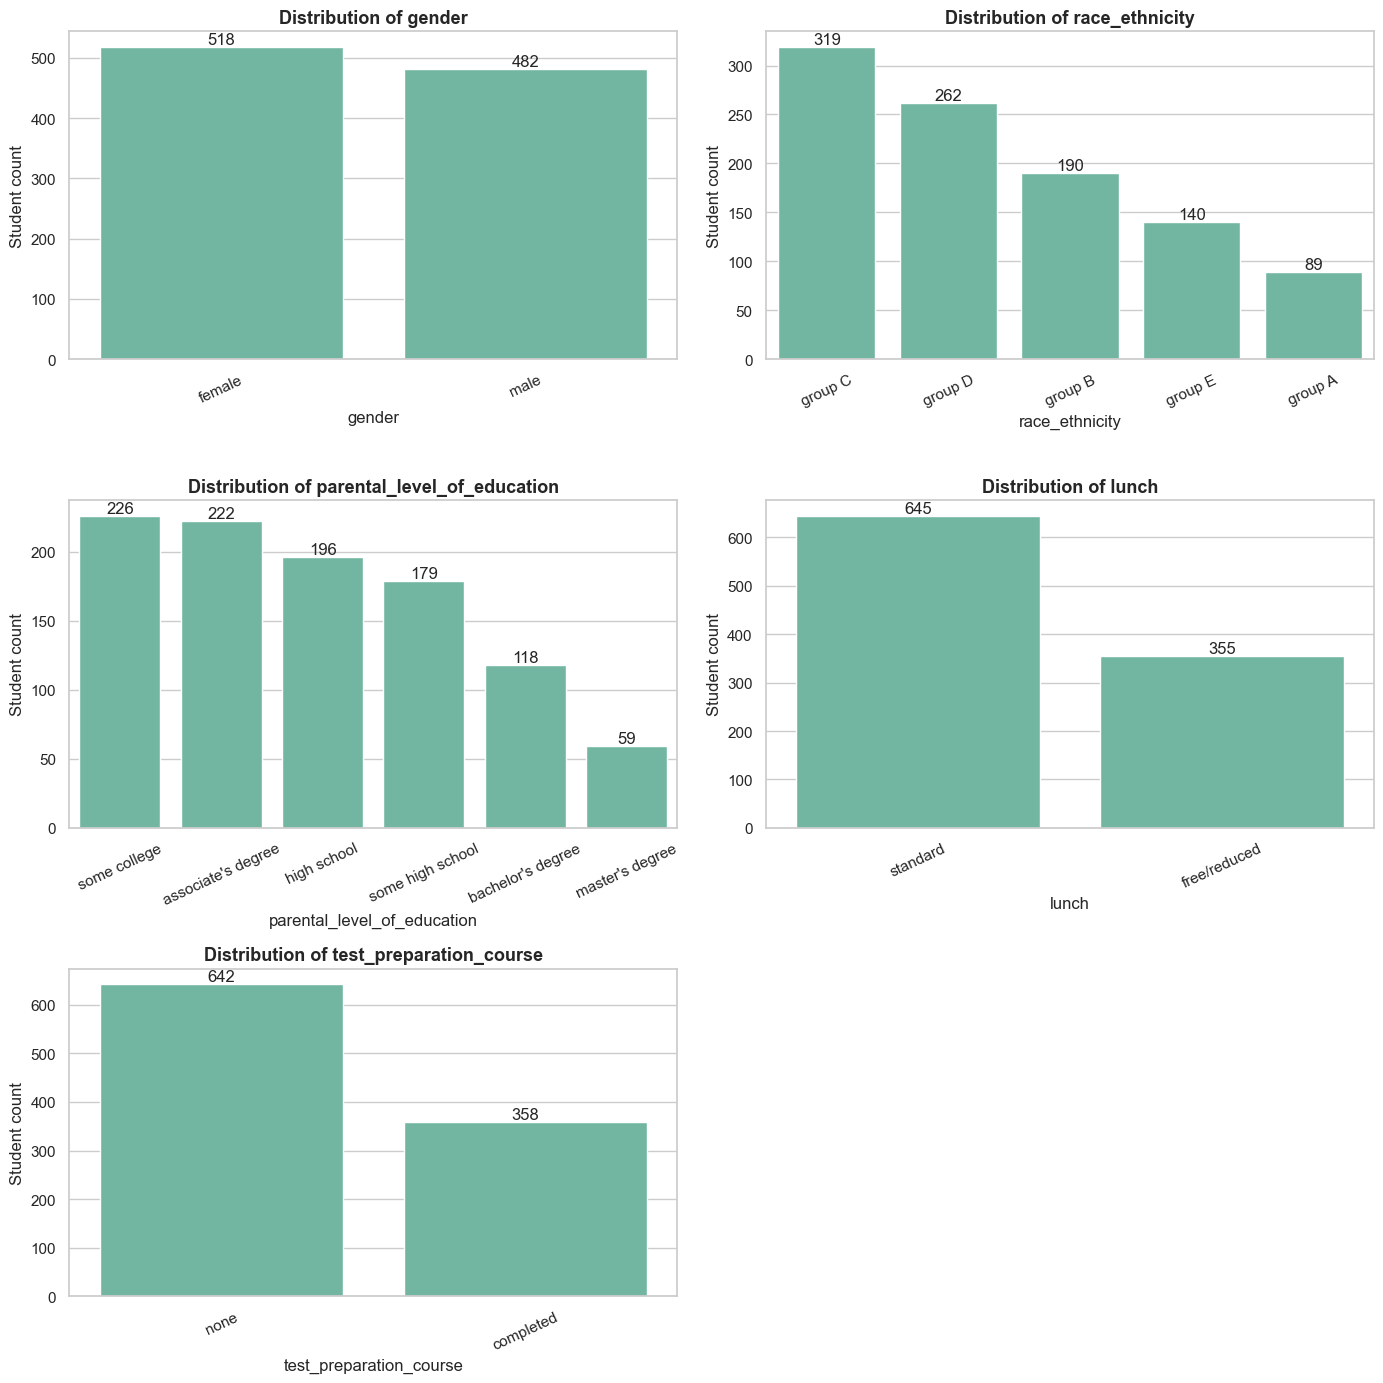

In [166]:
cat_plot_cols = ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(cat_plot_cols):
    order = df[col].value_counts().index
    ax = sns.countplot(data=df, x=col, order=order, ax=axes[i])
    ax.bar_label(ax.containers[0])
    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel('Student count')
    ax.tick_params(axis='x', rotation=25)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [183]:
for col in cat_plot_cols:
    pct = (df[col].value_counts(normalize=True) * 100).round(1)
    pct.index.name = None   # Remove the index name
    print(f"{col}:")
    print(pct.to_string())
    print()

# pct = df['gender'].value_counts(normalize=True)
# print(pct.index.name)

gender:
female   51.800
male     48.200

race_ethnicity:
group C   31.900
group D   26.200
group B   19.000
group E   14.000
group A    8.900

parental_level_of_education:
some college         22.600
associate's degree   22.200
high school          19.600
some high school     17.900
bachelor's degree    11.800
master's degree       5.900

lunch:
standard       64.500
free/reduced   35.500

test_preparation_course:
none        64.200
completed   35.800



**Insights — Univariate:**
- Score distributions are unimodal and roughly bell-shaped for all three subjects, with Math showing
  the most symmetric distribution and Reading/Writing showing mild negative skew (a tail of low scorers).
- The dataset is close to balanced by gender (~51.8% female / 48.2% male).
- `group C` is the largest ethnicity group (~31.9%), `group A` the smallest (~8.9%) — a class imbalance
  worth flagging for any downstream group-level modelling.
- ~64.5% of students had `standard` lunch and ~35.5% had `free/reduced` lunch.
- Only ~35.8% of students completed the test preparation course — the majority did not.


### 7. Bivariate and Multivariate Analysis

#### 7.1 Students performance by gender.

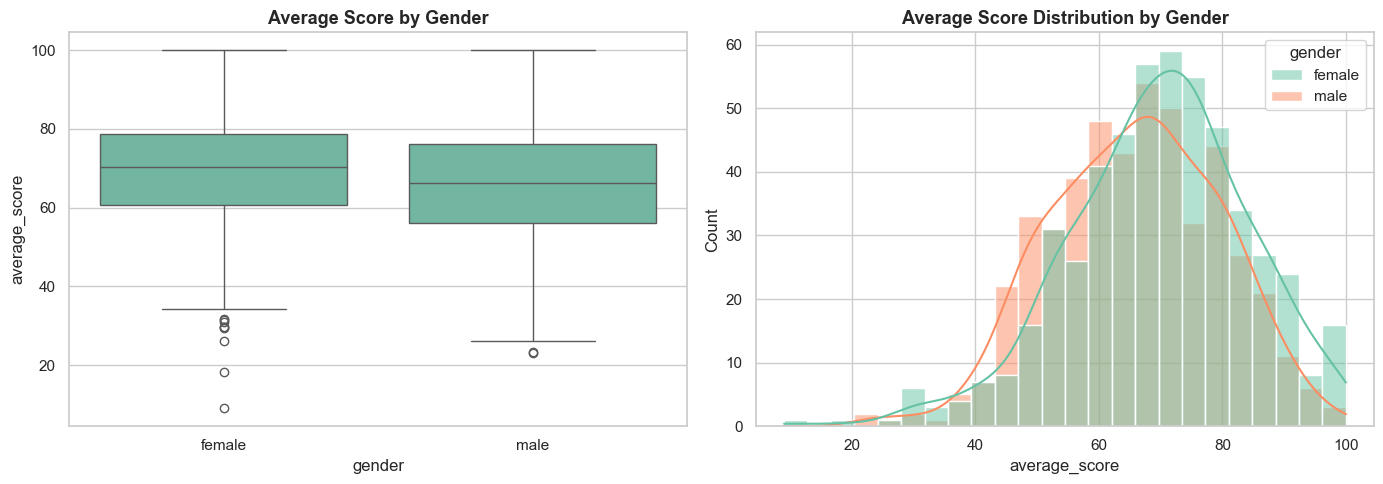

In [184]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='gender', y='average_score', ax=axs[0])
axs[0].set_title('Average Score by Gender')

sns.histplot(data=df, x='average_score', kde=True, hue='gender', ax=axs[1])
axs[1].set_title('Average Score Distribution by Gender')
plt.tight_layout()
plt.show()

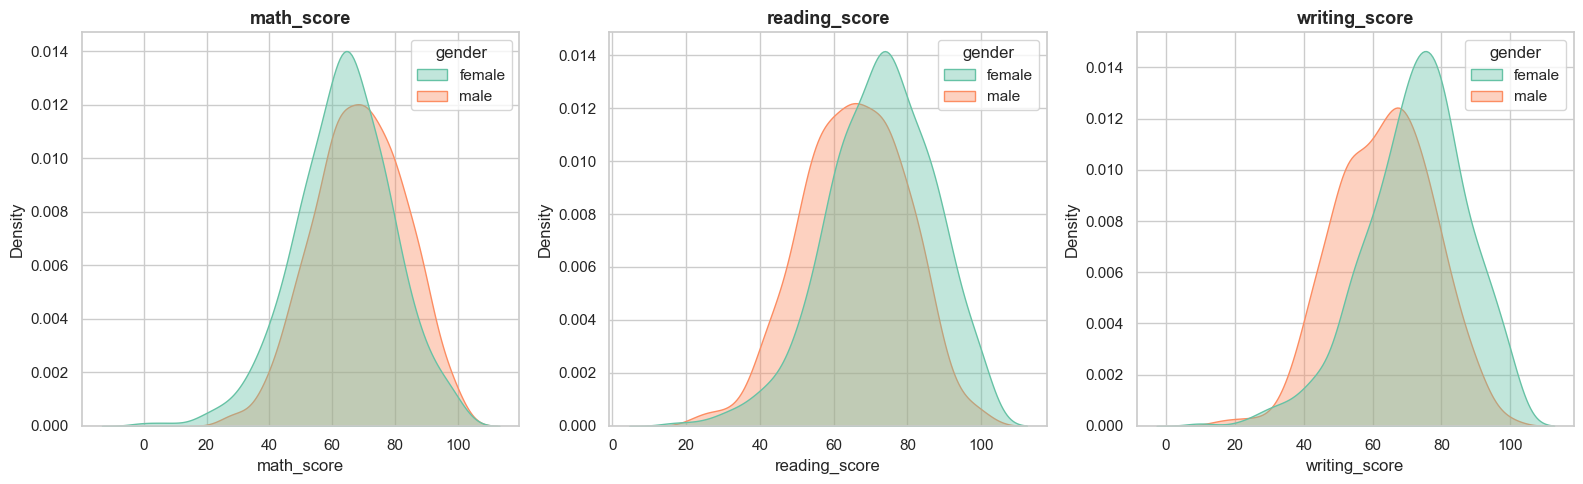

In [185]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axs, ['math_score', 'reading_score', 'writing_score']):
    sns.kdeplot(data=df, x=col, hue='gender', fill=True, alpha=0.4, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### 7.2 Performance by Race/Ethnicity

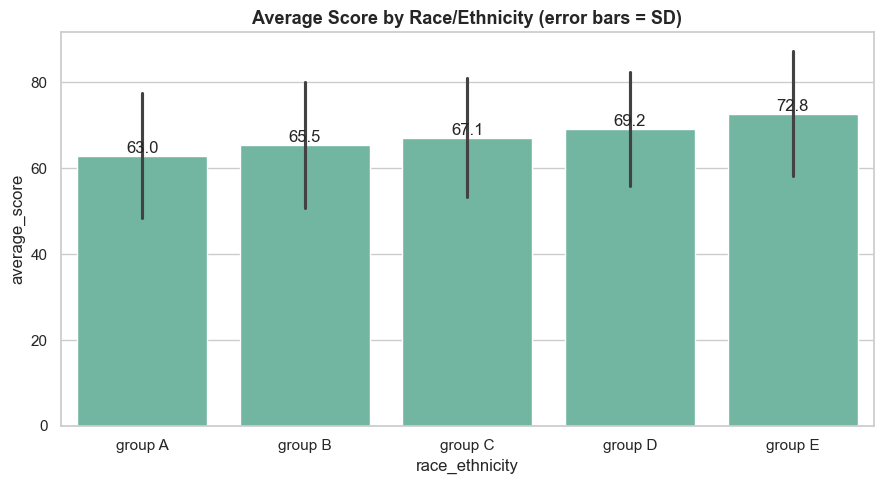

In [187]:
order = sorted(df.race_ethnicity.unique())
fig, ax = plt.subplots(figsize=(9, 5))
bp = sns.barplot(data=df, x='race_ethnicity', y='average_score', order=order, errorbar='sd', ax=ax)
for c in bp.containers:
    bp.bar_label(c, fmt='%.1f')
plt.title('Average Score by Race/Ethnicity (error bars = SD)')
plt.tight_layout()
plt.show()

#### 7.3 Performance by Perental Education

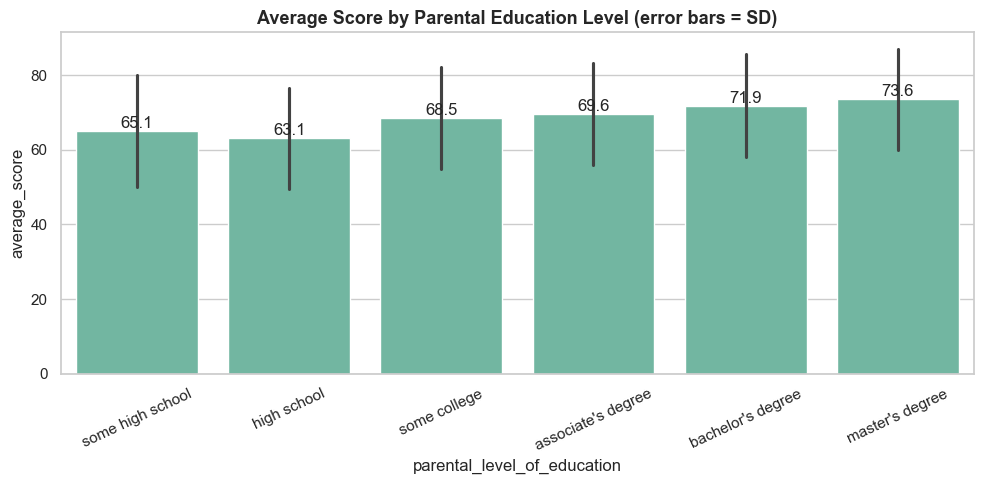

In [190]:
edu_order = ["some high school", "high school", "some college", "associate's degree",
             "bachelor's degree", "master's degree"]
fig, ax = plt.subplots(figsize=(10, 5))
bp = sns.barplot(data=df, x='parental_level_of_education', y='average_score', order=edu_order,
                  errorbar='sd', ax=ax)
for c in bp.containers:
    bp.bar_label(c, fmt='%.1f')
plt.xticks(rotation=25)
plt.title('Average Score by Parental Education Level (error bars = SD)')
plt.tight_layout()
plt.show()

#### 7.4 Performacne by Lunch and Test Preperation

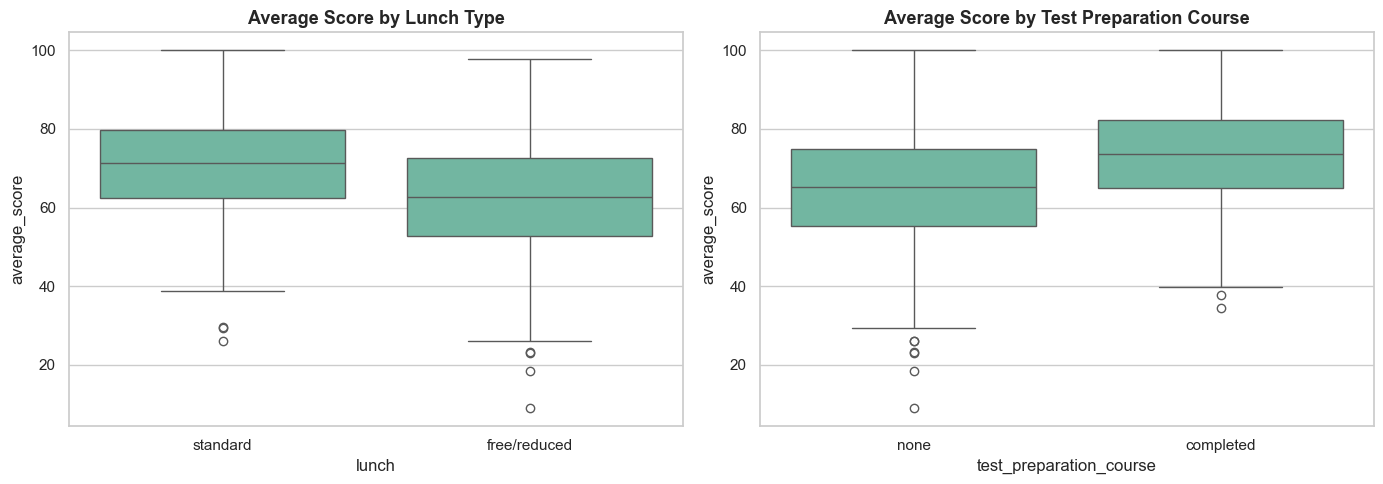

In [191]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='lunch', y='average_score', ax=axs[0])
axs[0].set_title('Average Score by Lunch Type')

sns.boxplot(data=df, x='test_preparation_course', y='average_score', ax=axs[1])
axs[1].set_title('Average Score by Test Preparation Course')
plt.tight_layout()
plt.show()

#### 7.5 Interaction Effects — Combining Predictors

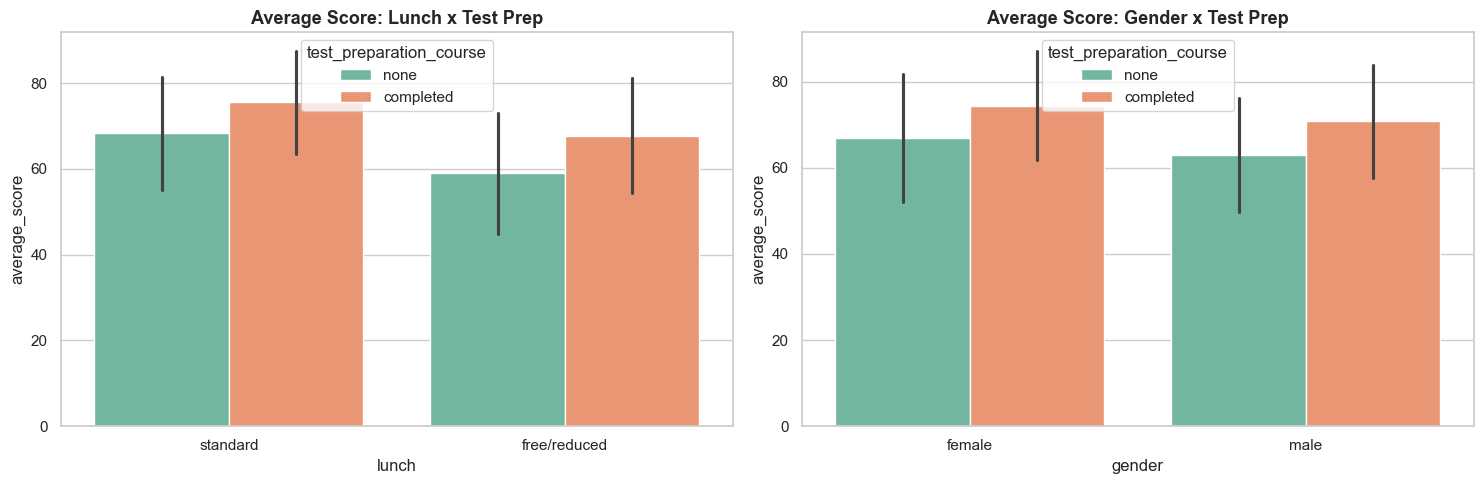

In [192]:
ig, axs = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=df, x='lunch', y='average_score', hue='test_preparation_course', errorbar='sd', ax=axs[0])
axs[0].set_title('Average Score: Lunch x Test Prep')

sns.barplot(data=df, x='gender', y='average_score', hue='test_preparation_course', errorbar='sd', ax=axs[1])
axs[1].set_title('Average Score: Gender x Test Prep')
plt.tight_layout()
plt.show()

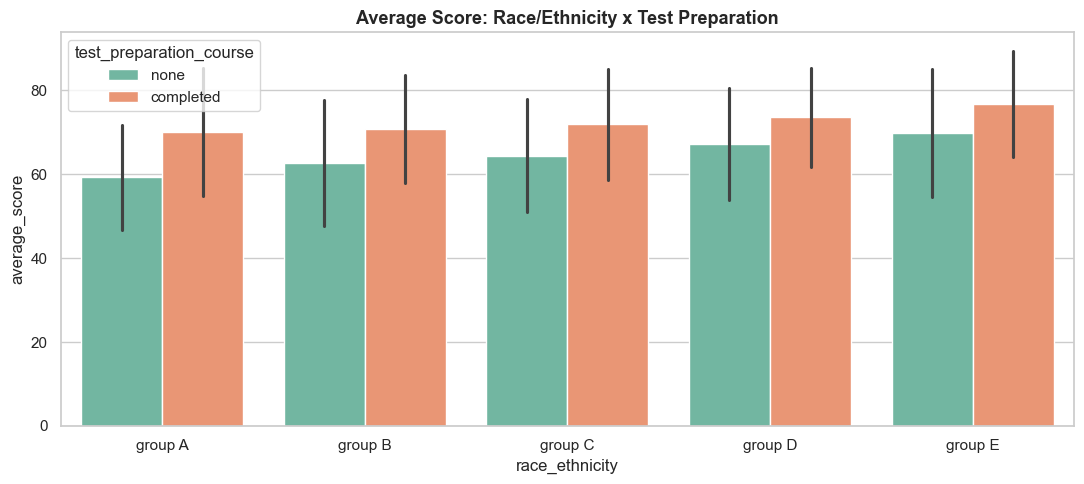

In [193]:
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=df, x='race_ethnicity', y='average_score', hue='test_preparation_course',
                  order=order, errorbar='sd')
plt.title('Average Score: Race/Ethnicity x Test Preparation')
plt.tight_layout()
plt.show()

**Insight:** The positive effect of test preparation is **consistent across every subgroup**
(every lunch type, gender, and ethnicity group) — students who complete the course outperform peers
in the same subgroup who don't.

### 7.6 Cross-tabulation Heatmap — Lunch vs Parental Education

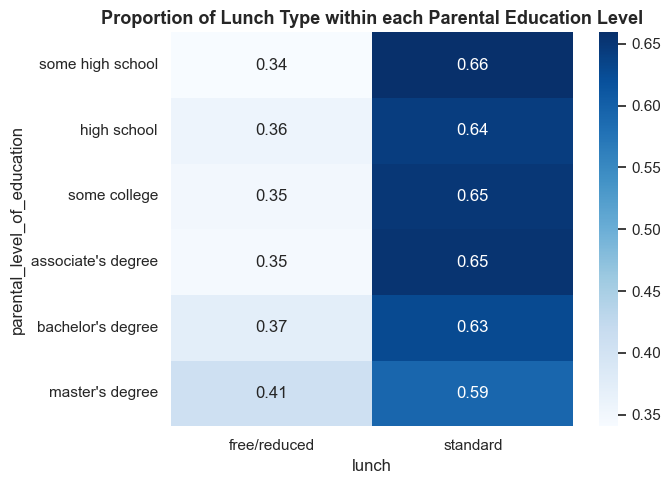

In [195]:
table = pd.crosstab(df['parental_level_of_education'], df['lunch'], normalize='index')
plt.figure(figsize=(7, 5))
sns.heatmap(table.loc[edu_order], annot=True, fmt='.2f', cmap='Blues')
plt.title('Proportion of Lunch Type within each Parental Education Level')
plt.tight_layout()
plt.show()

#### 8. Correlation & Multicollinearity Analysis

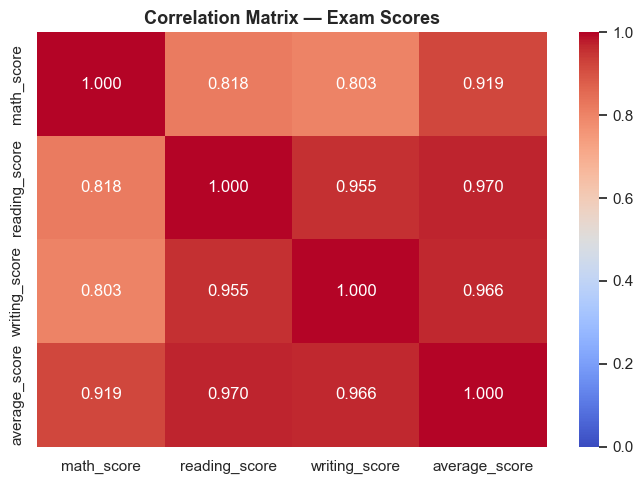

In [196]:
corr_cols = ['math_score', 'reading_score', 'writing_score', 'average_score']
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation Matrix — Exam Scores')
plt.tight_layout()
plt.show()

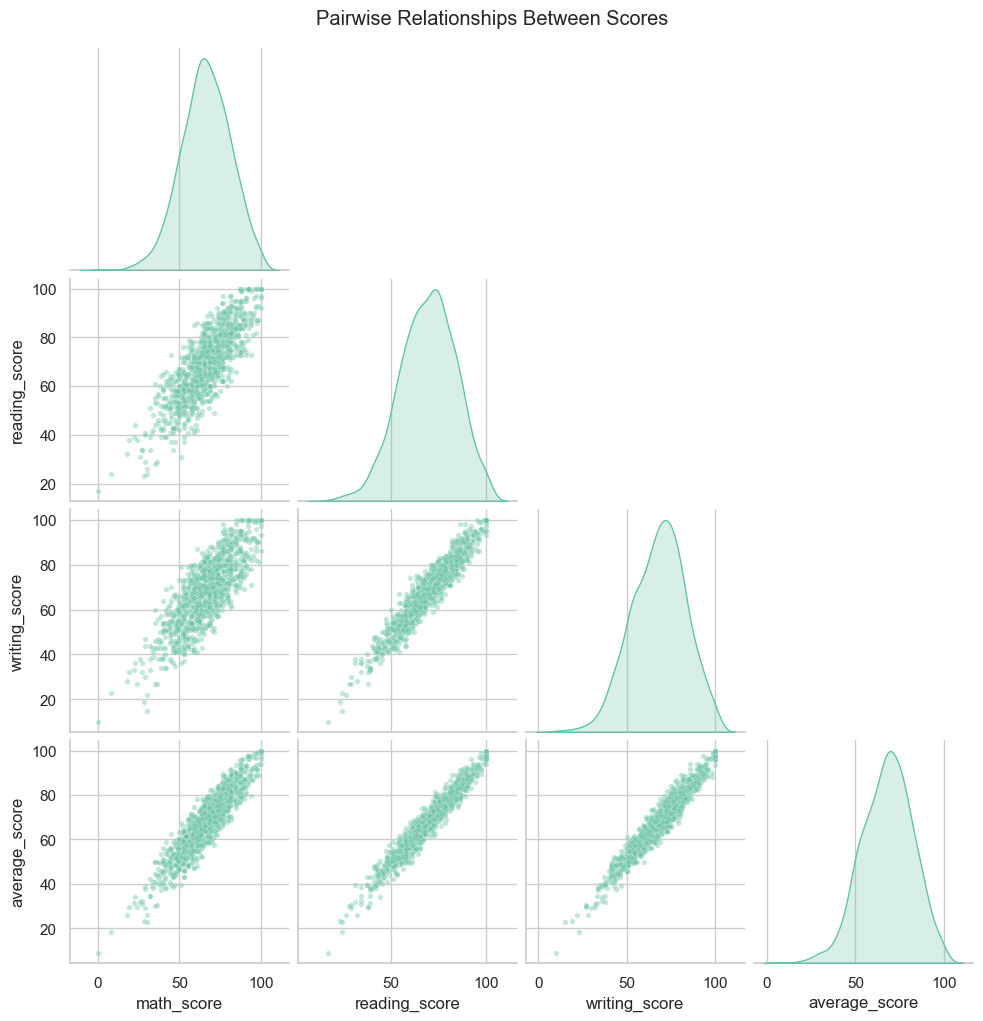

In [197]:
sns.pairplot(df[corr_cols], corner=True, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairwise Relationships Between Scores', y=1.02)
plt.show()

**Interpretation:** Reading and Writing scores are extremely strongly correlated (r≈0.95),
suggesting they largely measure overlapping literacy skills. Math correlates strongly but somewhat
less tightly with both (r≈0.80–0.82), consistent with Math drawing on a partly distinct skill set.
For any downstream predictive modelling, this **multicollinearity** means Reading and Writing carry
substantially redundant information — a model builder should be cautious about including all three
raw scores as independent features without regularization or dimensionality reduction.

#### 9. Top Peroformers and At-Risk Student

In [198]:
for col in ['math_score', 'reading_score', 'writing_score']:
    n_top = (df[col] >= 90).sum()
    print(f"Students scoring 90+ in {col.replace('_score','').title():10s}: {n_top} ({n_top/len(df)*100:.1f}%)")

print()
for col in ['math_score', 'reading_score', 'writing_score']:
    n_fail = (df[col] < PASS_MARK).sum()
    print(f"Students below pass mark ({PASS_MARK}) in {col.replace('_score','').title():10s}: {n_fail} ({n_fail/len(df)*100:.1f}%)")

Students scoring 90+ in Math      : 58 (5.8%)
Students scoring 90+ in Reading   : 79 (7.9%)
Students scoring 90+ in Writing   : 78 (7.8%)

Students below pass mark (33) in Math      : 19 (1.9%)
Students below pass mark (33) in Reading   : 11 (1.1%)
Students below pass mark (33) in Writing   : 12 (1.2%)


In [199]:
at_risk = df[df['pass_overall'] == 0]
print(f"At-risk students (fail at least one subject): {len(at_risk)} ({len(at_risk)/len(df)*100:.1f}%)\n")

print("At-risk student profile vs. overall population:")
comparison = pd.DataFrame({
    'at_risk_%': (at_risk[cat_plot_cols].apply(lambda s: s.value_counts(normalize=True)*100)).stack(),
})
for col in cat_plot_cols:
    print(f"\n{col}:")
    print(pd.concat([
        df[col].value_counts(normalize=True).mul(100).round(1).rename('overall_%'),
        at_risk[col].value_counts(normalize=True).mul(100).round(1).rename('at_risk_%')
    ], axis=1))

At-risk students (fail at least one subject): 22 (2.2%)

At-risk student profile vs. overall population:

gender:
        overall_%  at_risk_%
gender                      
female     51.800     68.200
male       48.200     31.800

race_ethnicity:
                overall_%  at_risk_%
race_ethnicity                      
group C            31.900     31.800
group D            26.200     13.600
group B            19.000     36.400
group E            14.000      9.100
group A             8.900      9.100

parental_level_of_education:
                             overall_%  at_risk_%
parental_level_of_education                      
some college                    22.600     22.700
associate's degree              22.200      4.500
high school                     19.600     27.300
some high school                17.900     40.900
bachelor's degree               11.800      4.500
master's degree                  5.900        NaN

lunch:
              overall_%  at_risk_%
lunch                